In [11]:
# Config
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load data and show data kernels
import numpy as np

npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ\Sample_2020-01-03.npz"

data = np.load(npz_path)

print("📂 File:", npz_path)
print("🔑 Keys:", data.files)
print("=" * 60)

# ===== LOAD DATA =====
arr = data['x']   # (8, H, W)
flood_map = data['y']  # label

print("📦 Array shape:", arr.shape)
print("🧪 Dtype:", arr.dtype)
print("=" * 60)

# ===== CHANNEL NAMES =====
channel_names = [
    "Rain (T)",
    "Rain (T-1)",
    "Rain (T-2)",
    "Soil Moisture",
    "Tide",
    "DEM",
    "Slope",
    "Flow Acc"
]

# ===== CHECK LAYOUT =====
if arr.ndim != 3:
    raise ValueError("❌ Data không phải 3D")

if arr.shape[0] != 8:
    raise ValueError("❌ Không phải 8 channels")

print("✅ Layout: (C, H, W)")
print("=" * 60)

# ===== PHÂN TÍCH TỪNG CHANNEL =====
for i, name in enumerate(channel_names):
    ch = arr[i]
    
    print(f"📊 {name}")
    print(" Shape:", ch.shape)
    print(" Min:", np.nanmin(ch))
    print(" Max:", np.nanmax(ch))
    print(" Mean:", np.nanmean(ch))
    print(" Std:", np.nanstd(ch))
    print(" NaN count:", np.isnan(ch).sum())
    
    # ===== SPECIAL CHECK =====
    
    # Flood-like check (binary)
    unique_vals = np.unique(ch[~np.isnan(ch)])
    
    if len(unique_vals) < 10:
        print(" Unique values:", unique_vals[:10])
    else:
        print(" Unique sample:", unique_vals[:10])
    
    # ===== AUTO COMMENT =====
    if i in [0, 1] and np.nanmax(ch) == 0:
        print(" ⚠️ Channel EMPTY (Rain missing)")
    
    if i == 5:
        print(" 🏔️ DEM → dùng cho ROI")
    
    if i == 6:
        print(" ⛰️ Slope → dùng cho ROI")
    
    if i == 7:
        print(" 🌊 Flow Acc → gần sông")
    
    print("-" * 60)

# ===== FLOOD LABEL =====
print("\n🌊 FLOOD LABEL (y)")
print(" Shape:", flood_map.shape)
print(" Min:", np.nanmin(flood_map))
print(" Max:", np.nanmax(flood_map))
print(" Mean:", np.nanmean(flood_map))

# Binary check
unique_y = np.unique(flood_map[~np.isnan(flood_map)])
print(" Unique values:", unique_y[:10])

print("=" * 60)

# ===== FLOOD RATIO =====
flood_ratio = np.mean(flood_map > 0)
print(f"🔥 Flood ratio: {flood_ratio:.4f}")

📂 File: D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ\Sample_2020-01-03.npz
🔑 Keys: ['x', 'y']
📦 Array shape: (8, 1115, 1856)
🧪 Dtype: float32
✅ Layout: (C, H, W)
📊 Rain (T)
 Shape: (1115, 1856)
 Min: 0.0
 Max: 0.0
 Mean: 0.0
 Std: 0.0
 NaN count: 0
 Unique values: [0.]
 ⚠️ Channel EMPTY (Rain missing)
------------------------------------------------------------
📊 Rain (T-1)
 Shape: (1115, 1856)
 Min: 0.0
 Max: 11.961194
 Mean: 7.473307
 Std: 4.0124345
 NaN count: 0
 Unique sample: [0.0000000e+00 4.4738808e-06 1.4197010e-05 2.3920140e-05 3.3643268e-05
 4.3366399e-05 5.3089527e-05 5.6287503e-05 6.2812658e-05 7.2535790e-05]
------------------------------------------------------------
📊 Rain (T-2)
 Shape: (1115, 1856)
 Min: 0.0
 Max: 10.2442045
 Mean: 6.53542
 Std: 3.4988449
 NaN count: 0
 Unique sample: [0.0000000e+00 3.9413349e-06 1.2507077e-05 2.1072819e-05 2.9638562e-05
 3.8204307e-05 4.6770048e-05 5.0043516e-05 5.5335790e-05 6.3901534e-05]
-----------------------------

Array shape: (8, 1115, 1856)


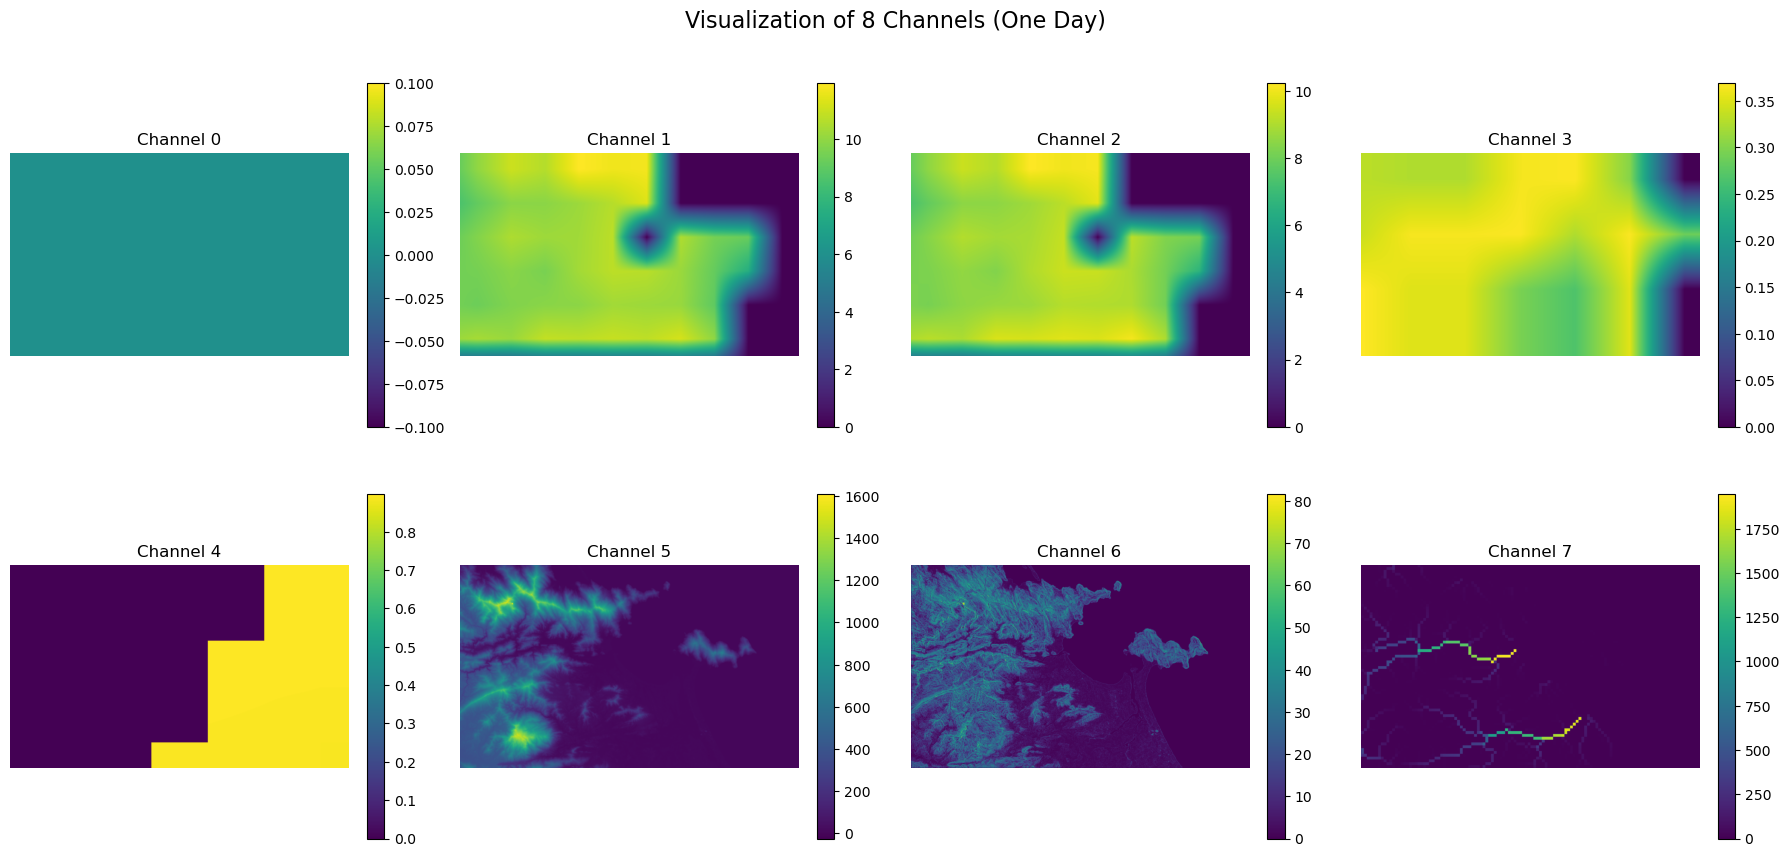

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ====== CONFIG ======
npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ\Sample_2020-01-03.npz"

# ====================
data = np.load(npz_path)
arr = data[data.files[0]]  # lấy array chính

print("Array shape:", arr.shape)

# Xác định layout
if arr.shape[0] == 8:
    CHANNEL_FIRST = True   # (C, H, W)
elif arr.shape[-1] == 8:
    CHANNEL_FIRST = False  # (H, W, C)
else:
    raise ValueError("❌ Không tìm thấy 8 channel")

# ====== VISUALIZE ======
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, ax in enumerate(axes.flat):
    if CHANNEL_FIRST:
        ch = arr[i]
    else:
        ch = arr[:, :, i]

    im = ax.imshow(ch, cmap="viridis")
    ax.set_title(f"Channel {i}", fontsize=12)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Visualization of 8 Channels (One Day)", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

npz_path = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ\Sample_2020-01-03.npz"

data = np.load(npz_path)
arr = data[data.files[0]]

# xác định layout
if arr.shape[0] == 8:
    CHANNEL_FIRST = True
elif arr.shape[-1] == 8:
    CHANNEL_FIRST = False
else:
    raise ValueError("Không tìm thấy 8 channel")

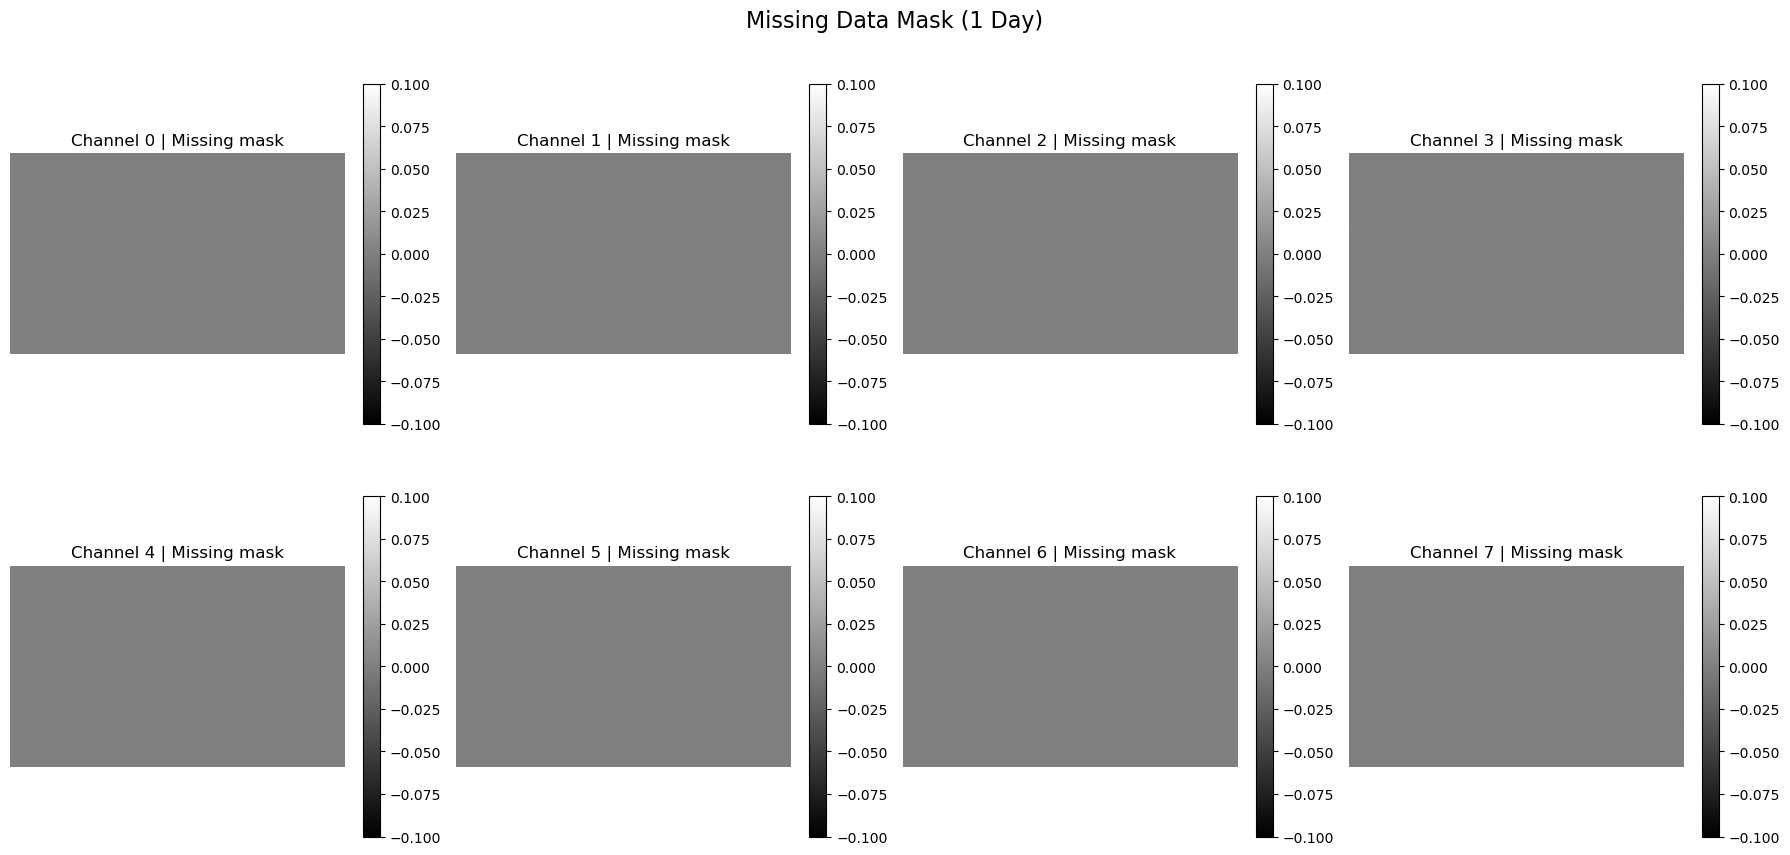

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, ax in enumerate(axes.flat):
    ch = arr[i] if CHANNEL_FIRST else arr[:, :, i]
    mask = np.isnan(ch)

    im = ax.imshow(mask, cmap="gray")
    ax.set_title(f"Channel {i} | Missing mask")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Missing Data Mask (1 Day)", fontsize=16)
plt.tight_layout()
plt.show()

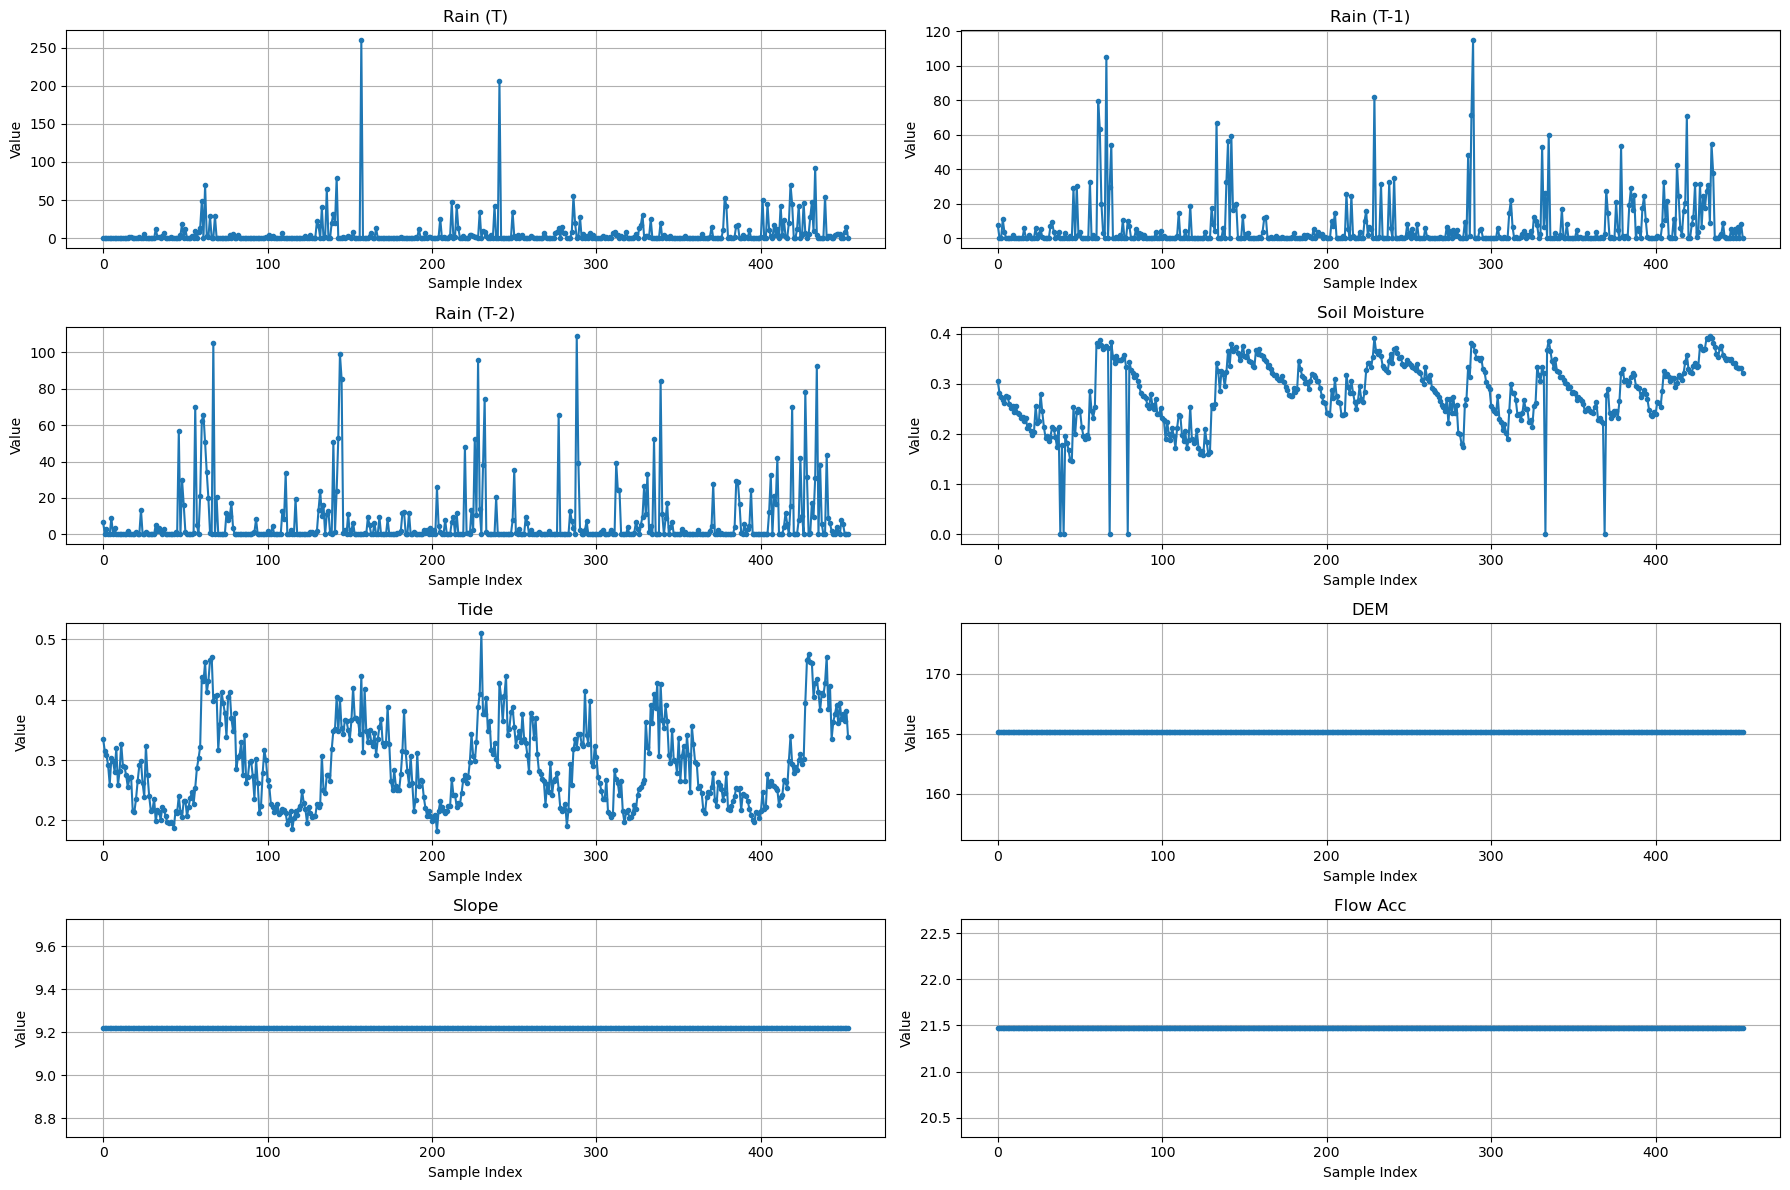

In [8]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== CONFIG =====
folder = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ"

channel_names = [
    "Rain (T)",
    "Rain (T-1)",
    "Rain (T-2)",
    "Soil Moisture",
    "Tide",
    "DEM",
    "Slope",
    "Flow Acc"
]

# ===== EXTRACT DATE =====
def extract_date(filename):
    match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
    if match:
        return pd.to_datetime(match.group())
    return None


# ===== LOAD DATA =====
records = []

files = [f for f in os.listdir(folder) if f.endswith(".npz")]

for file in files:
    date = extract_date(file)
    if date is None:
        continue
    
    path = os.path.join(folder, file)
    
    try:
        data = np.load(path)
        arr = data['x']
        
        row = {"date": date}
        
        for i, name in enumerate(channel_names):
            row[name] = np.nanmean(arr[i])
        
        records.append(row)
    
    except Exception as e:
        print("❌ Error:", file, e)


# ===== DATAFRAME =====
df = pd.DataFrame(records)
df = df.sort_values("date").reset_index(drop=True)

# ===== SAMPLE INDEX =====
df["sample_idx"] = df.index


# ===== VISUALIZE =====
plt.figure(figsize=(18, 12))

for i, name in enumerate(channel_names):
    plt.subplot(4, 2, i+1)
    
    plt.plot(df["sample_idx"], df[name], marker='o', markersize=3)
    
    plt.title(name)
    plt.xlabel("Sample Index")
    plt.ylabel("Value")
    plt.grid(True)

plt.tight_layout()
plt.show()

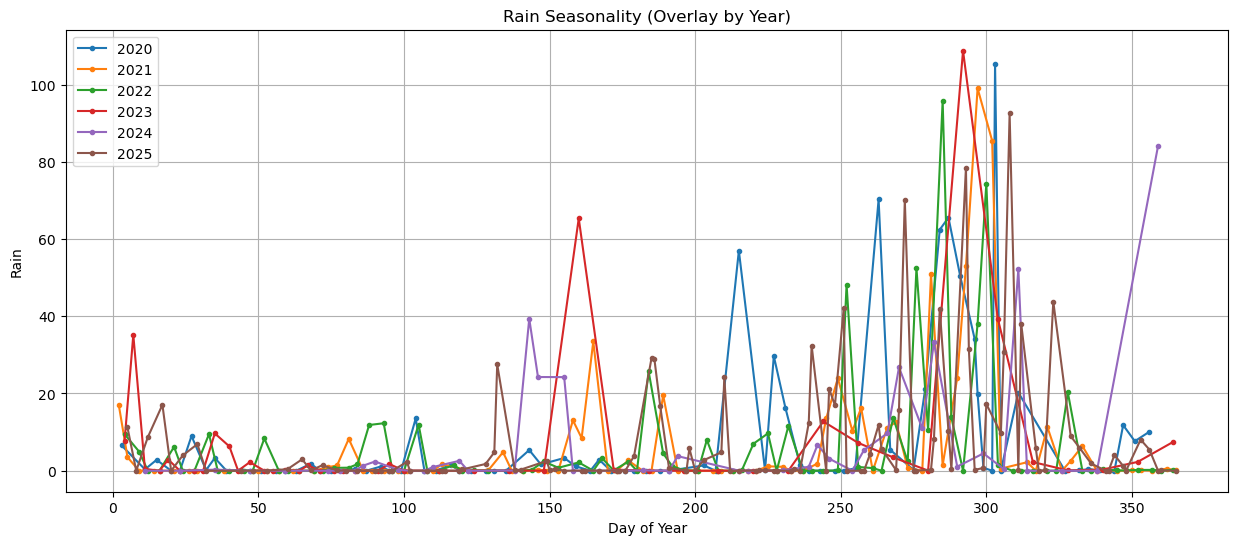

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== CONFIG =====
folder = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ"

# ===== EXTRACT DATE =====
def extract_date(filename):
    match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
    if match:
        return pd.to_datetime(match.group())
    return None


# ===== LOAD RAIN =====
records = []

files = [f for f in os.listdir(folder) if f.endswith(".npz")]

for file in files:
    date = extract_date(file)
    if date is None:
        continue
    
    path = os.path.join(folder, file)
    
    try:
        data = np.load(path)
        arr = data['x']
        
        # ⚠️ dùng Rain (T-2) vì T bị empty
        rain = arr[2]
        
        records.append({
            "date": date,
            "rain": np.nanmean(rain)
        })
    
    except Exception as e:
        print("❌ Error:", file, e)


df = pd.DataFrame(records).sort_values("date")

# ===== ADD TIME FEATURES =====
df["year"] = df["date"].dt.year
df["dayofyear"] = df["date"].dt.dayofyear

# ===== PLOT =====
plt.figure(figsize=(15,6))

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    
    plt.plot(
        df_year["dayofyear"],
        df_year["rain"],
        marker='o',
        markersize=3,
        label=str(year)
    )

plt.title("Rain Seasonality (mm)")
plt.xlabel("Day of Year")
plt.ylabel("Rain")
plt.legend()
plt.grid(True)

plt.show()

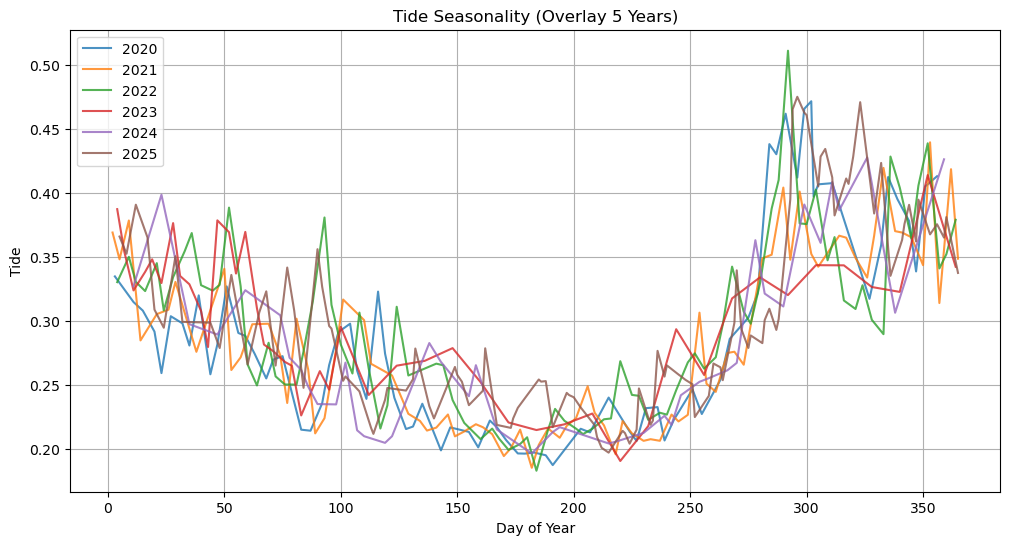

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== CONFIG =====
folder = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ"

# ===== EXTRACT DATE =====
def extract_date(filename):
    match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
    if match:
        return pd.to_datetime(match.group())
    return None


# ===== LOAD TIDE =====
records = []

files = [f for f in os.listdir(folder) if f.endswith(".npz")]

for file in files:
    date = extract_date(file)
    if date is None:
        continue
    
    path = os.path.join(folder, file)
    
    try:
        data = np.load(path)
        arr = data['x']
        
        tide = np.nanmean(arr[4])  # Channel 4 = Tide
        
        records.append({
            "date": date,
            "tide": tide
        })
    
    except Exception as e:
        print("❌ Error:", file, e)


# ===== DATAFRAME =====
df = pd.DataFrame(records).sort_values("date")

df["year"] = df["date"].dt.year
df["dayofyear"] = df["date"].dt.dayofyear


# ===== VISUALIZE =====
plt.figure(figsize=(12,6))

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    
    plt.plot(
        df_year["dayofyear"],
        df_year["tide"],
        label=str(year),
        alpha=0.8
    )

plt.title("Tide Seasonality (m)")
plt.xlabel("Day of Year")
plt.ylabel("Tide")
plt.legend()
plt.grid(True)

plt.show()

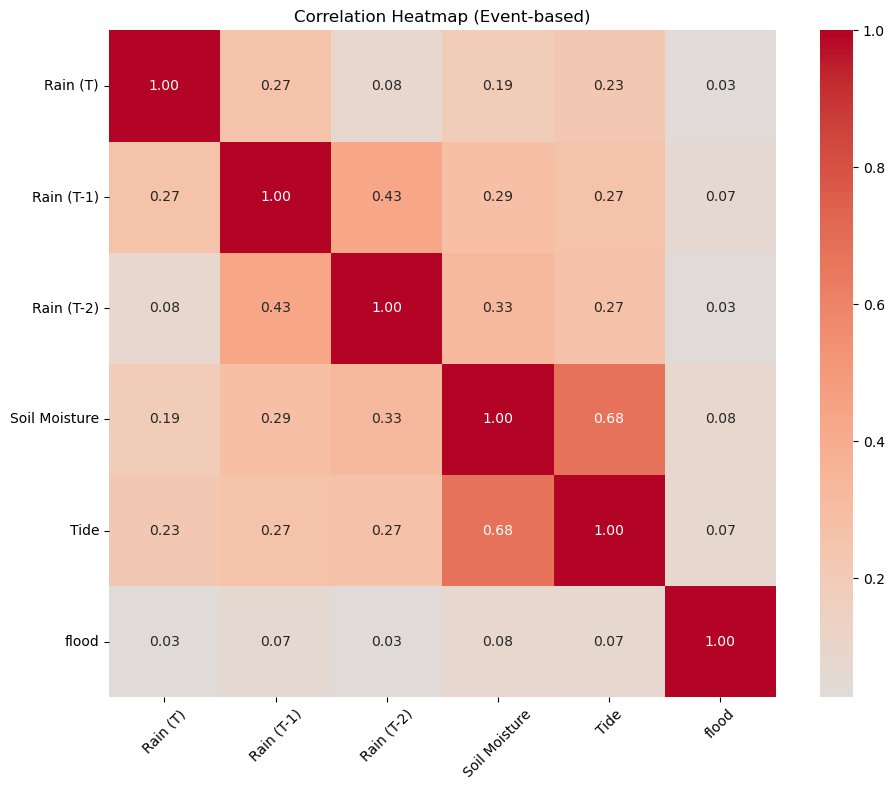

In [12]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== CONFIG =====
folder = r"D:\University\Machine Learning\Dataset\Data_Training_Raw_NPZ"

channel_names = [
    "Rain (T)",
    "Rain (T-1)",
    "Rain (T-2)",
    "Soil Moisture",
    "Tide",
]

# ===== EXTRACT DATE =====
def extract_date(filename):
    match = re.search(r"\d{4}-\d{2}-\d{2}", filename)
    if match:
        return pd.to_datetime(match.group())
    return None


# ===== LOAD DATA =====
records = []

files = [f for f in os.listdir(folder) if f.endswith(".npz")]

for file in files:
    date = extract_date(file)
    if date is None:
        continue
    
    path = os.path.join(folder, file)
    
    try:
        data = np.load(path)
        arr = data['x']
        y = data['y']
        
        row = {"date": date}
        
        for i, name in enumerate(channel_names):
            row[name] = np.nanmean(arr[i])
        
        row["flood"] = np.nanmean(y)
        
        records.append(row)
    
    except Exception as e:
        print("❌ Error:", file, e)


# ===== DATAFRAME =====
df = pd.DataFrame(records)
df = df.sort_values("date").reset_index(drop=True)

# ===== CORRELATION =====
corr = df.drop(columns=["date"]).corr()

# ===== HEATMAP =====
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,          # hiện số
    fmt=".2f",           # 2 chữ số thập phân
    cmap="coolwarm",     # màu xanh-đỏ
    center=0,            # centered tại 0
    square=True
)

plt.title("Correlation Heatmap (Event-based)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()